In [1]:
from pyvi import ViTokenizer

/home/hoang/anaconda3/envs/ML-Training/lib/python3.11/site-packages/pyvi/ViTokenizer.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model = pickle.load(fin)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_files

from sklearn import svm
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ShuffleSplit, learning_curve

%matplotlib inline

In [3]:
data_train = load_files(container_path = "../data/news_1135", encoding = "utf-8")

print(data_train.filenames)
print()


print("Tong so file: {}" .format( len(data_train.filenames)))
print("Danh sách nhãn và id tương ứng: ", [(idx, name) for idx, name in enumerate(data_train.target_names)] )

['../data/news_1135/Tin kh†c/0218e1df21ce358b9c6485176a48f1fcaeedef67.txt'
 '../data/news_1135/Khoa học - Công nghệ/bf9889f5f2ffd6c92fa877d35ef0ef5f34f0666d.txt'
 '../data/news_1135/Tin kh†c/d74aab054ffe9f8661df13bc52b438b48a63fe48.txt'
 ...
 '../data/news_1135/Thời sự/a06c1ec4c146d3b4eb5070a1967e10e5e21bdc5b.txt'
 '../data/news_1135/Sức khỏe/4187c4a1d528fd9ea4630d2709229df0b0d09c3d.txt'
 '../data/news_1135/Thể thao/7adaf0c561796f2411340150f18417543ad4403c.txt']

Tong so file: 1135
Danh sách nhãn và id tương ứng:  [(0, 'Giải trí'), (1, 'Khoa học - Công nghệ'), (2, 'Kinh tế'), (3, 'Pháp luật'), (4, 'Sức khỏe'), (5, 'Thể thao'), (6, 'Thời sự'), (7, 'Tin kh†c'), (8, 'Độc giả'), (9, 'Đời sống - Xã hội')]


In [4]:
with open("../data/vietnamese-stopwords.txt", "r", encoding="utf-8") as f:
    stop_words = f.readlines()

stop_words = [word.strip().replace(" ", "_") for word in stop_words]

print("10 stop words đầu tiên: ", stop_words[:10])

10 stop words đầu tiên:  ['a_lô', 'a_ha', 'ai', 'ai_ai', 'ai_nấy', 'ai_đó', 'alô', 'amen', 'anh', 'anh_ấy']


In [5]:
module_count_vector = CountVectorizer(stop_words=stop_words)
model_rf_process = Pipeline([('vect', module_count_vector), ('tfidf', TfidfTransformer())])

In [6]:
data_preprocessed = model_rf_process.fit_transform(data_train.data, data_train.target)

print("10 tu dau tien trong tu dien: ")

for i, (k, v) in enumerate(module_count_vector.vocabulary_.items()):
    print(i, ": ", (k, v))
    if i >= 10:
        break

10 tu dau tien trong tu dien: 
0 :  ('dân_trí', 6928)
1 :  ('sở', 17869)
2 :  ('gd', 7729)
3 :  ('đt', 23214)
4 :  ('tỉnh', 20851)
5 :  ('gia_lai', 7816)
6 :  ('văn_bản', 21779)
7 :  ('2258', 858)
8 :  ('sgdđt', 17039)
9 :  ('vp', 21572)
10 :  ('chấn_chỉnh', 4971)


In [7]:
data_preprocessed2 = TfidfVectorizer(stop_words=stop_words).fit_transform(data_train.data, data_train.target)

def sort_data_by_tfidf(data_preprocessed, feature_names):
    sorted_indices = np.argsort(data_preprocessed.toarray(), axis=1)[:, ::-1]
    sorted_features = np.array(feature_names)[sorted_indices]
    return sorted_features

data_preprocessed2 = sort_data_by_tfidf(data_preprocessed2, module_count_vector.get_feature_names_out())
print("10 tu co tf-idf cao nhat trong van ban dau tien: ", data_preprocessed2[0][:10])

10 tu co tf-idf cao nhat trong van ban dau tien:  ['sách' 'học_sinh' 'tuyệt_đối' 'phụ_huynh' 'nhà_trường' 'gia_lai'
 'tiếp_thị' 'sở' 'giáo_dục' 'tham_khảo']


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data_preprocessed, data_train.target, test_size=0.2)
model_svm = svm.SVC(kernel='linear', C = 1.0)
model_svm.fit(X_train, y_train)
accuracy = model_svm.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(accuracy * 100))


Accuracy: 87.22%


In [9]:
text = "Công Phượng ghi bàn cho đội tuyển Việt Nam"
text_tokenized = ViTokenizer.tokenize(text)

print("Text gốc: ", text)
print("Text đã được token hóa: ", text_tokenized)


Text gốc:  Công Phượng ghi bàn cho đội tuyển Việt Nam
Text đã được token hóa:  Công Phượng ghi_bàn cho đội_tuyển Việt_Nam


In [10]:
label = model_svm.predict(model_rf_process.transform([text_tokenized]))
print("Dự đoán nhãn cho câu: ", label, " - ", data_train.target_names[label[0]])

Dự đoán nhãn cho câu:  [5]  -  Thể thao


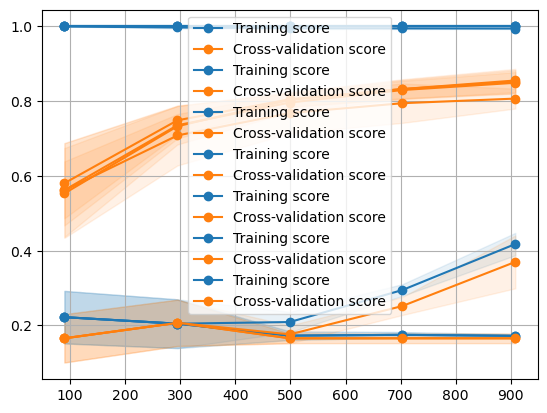

In [ ]:
def get_cmap(n):
    return 'C' + str(n)

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5), new_plot = False):
    if new_plot:
        #plt.figure()
        plt.title(title)
        plt.xlabel("Training examples")
        plt.ylabel("Accuracy")
        plt.grid()
    if ylim is not None:
        plt.ylim(*ylim)

    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color=get_cmap(0))
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1,
                     color=get_cmap(1))
    plt.plot(train_sizes, train_scores_mean, 'o-', color=get_cmap(0),
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color=get_cmap(1),
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

list_C = [0.001, 0.01, 0.1, 1, 5.0, 10.0, 100.0]
title = "Learning Curves (SVM)"

for i, C in enumerate(list_C):
    text_clf = Pipeline([('clf', svm.SVC(kernel='linear', C=C))])
    plot_learning_curve(text_clf, title + " (C={})".format(C), data_preprocessed, data_train.target, cv=ShuffleSplit(n_splits=5, test_size=0.2, random_state=0))


Classification report for classifier SVC(gamma=0.001):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.99      0.97      0.98        91
           2       0.99      0.99      0.99        86
           3       0.98      0.87      0.92        91
           4       0.99      0.96      0.97        92
           5       0.95      0.97      0.96        91
           6       0.99      0.99      0.99        91
           7       0.96      0.99      0.97        89
           8       0.94      1.00      0.97        88
           9       0.93      0.98      0.95        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899


Confusion matrix:
[[87  0  0  0  1  0  0  0  0  0]
 [ 0 88  1  0  0  0  0  0  1  1]
 [ 0  0 85  1  0  0  0  0  0  0]
 [ 0  0  0 79  0  3  0  4  5  0]
 [ 0  0  0  0 88  0  0  0  0  4]
 [

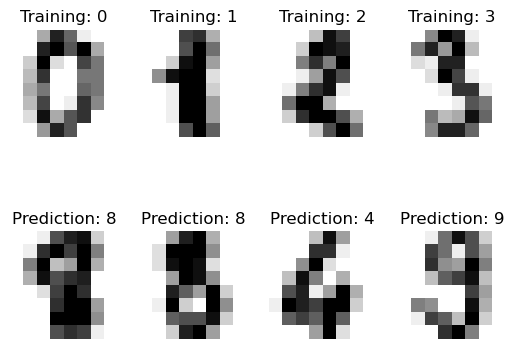

In [12]:
import matplotlib.pyplot as plt

from sklearn import datasets, svm, metrics

digits = datasets.load_digits()

images_and_labels = list(zip(digits.images, digits.target))
for index, (image, label) in enumerate(images_and_labels[:4]):
    plt.subplot(2, 4, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Training: %i' % label)

n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))
classifier = svm.SVC(gamma=0.001)
X_train, X_test, y_train, y_test = train_test_split(data, digits.target, test_size=0.5, shuffle=False)
classifier.fit(X_train, y_train)
expected = y_test
predicted = classifier.predict(X_test)
print("Classification report for classifier %s:\n%s\n"
      % (classifier, metrics.classification_report(expected, predicted)))
print("Confusion matrix:\n%s" % metrics.confusion_matrix(expected, predicted))
images_and_predictions = list(zip(digits.images[n_samples // 2:], predicted))
for index, (image, prediction) in enumerate(images_and_predictions[:4]):
    plt.subplot(2, 4, index + 5)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Prediction: %i' % prediction)

plt.show()